# ICU Length of Stay Prediction — Training, Validation, and Hyperparameter Tuning

**Objective:** Train, compare, tune, evaluate, and interpret regression models for ICU **Length of Stay (LOS)** prediction using the preprocessed `train.csv` and `test.csv` datasets.

## Table of Contents

1. [Project Context](#Project-Context)  
2. [Notebook Goals](#Notebook-Goals)  
3. [Configuration and Imports](#Configuration-and-Imports)  
4. [Load Training and Test Data](#Load-Training-and-Test-Data)  
5. [Initial Data Audit](#Initial-Data-Audit)  
6. [Feature and Target Definition](#Feature-and-Target-Definition)  
7. [Cross-Validation Strategy](#Cross-Validation-Strategy)  
8. [Baseline Models](#Baseline-Models)  
9. [Cross-Validated Benchmarking](#Cross-Validated-Benchmarking)  
10. [Fit Baseline Models and Evaluate on Test Set](#Fit-Baseline-Models-and-Evaluate-on-Test-Set)  
11. [Hyperparameter Tuning with Optuna](#Hyperparameter-Tuning-with-Optuna)  
12. [Final Model Training and Test Evaluation](#Final-Model-Training-and-Test-Evaluation)  
13. [Model Interpretation](#Model-Interpretation)  
14. [Save Results and Artifacts](#Save-Results-and-Artifacts)  
15. [Final Remarks](#Final-Remarks)

## Project Context

The target variable is **`LOS`**, representing ICU **Length of Stay**.  
Each row corresponds to a single **`ICUSTAY_ID`**, meaning that the dataset is already structured at the ICU-stay level.

The preprocessing stage has already:

- restricted the time-dependent data to the first **24 hours** of the ICU stay,
- aggregated ICU event measurements into tabular features,
- added demographic and admission context,
- encoded categorical variables,
- produced train/test CSV files.


## Notebook Goals

This notebook is designed to support a strong and defendable modeling phase.  
The workflow includes:

- loading the prepared datasets,
- verifying data integrity,
- defining features and target,
- benchmarking multiple regression models,
- preventing patient leakage during validation with **GroupKFold**,
- optimizing selected models with **Optuna**,
- evaluating the final model on the held-out test set,
- interpreting model behavior,
- saving the main outputs for reporting and reproducibility.

In [1]:
from pathlib import Path
import warnings
import json
import time
import os
import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

from sklearn.base import clone
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

c:\Users\catar\OneDrive\Ambiente de Trabalho\fcup\3 ano\2\CDLE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

print(ROOT_DIR)

c:\Users\catar\OneDrive\Ambiente de Trabalho\fcup\3 ano\2\CDLE\ICU-LengthOfStay-Prediction


In [3]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

ID_COLS = ["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID"]
TARGET_COL = "LOS"

ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data" / "processed"
MODELS_DIR = ROOT_DIR / "models"

FEATURE_SET = "9tables"
WINDOW_SIZE = "24h"
EXPERIMENT_NAME = f"{FEATURE_SET}_{WINDOW_SIZE}"

EXPERIMENT_DATA_DIR = DATA_DIR / EXPERIMENT_NAME
EXPERIMENT_MODELS_DIR = MODELS_DIR / EXPERIMENT_NAME
EXPERIMENT_DATA_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = EXPERIMENT_DATA_DIR / f"features.csv"
TRAIN_PATH = EXPERIMENT_DATA_DIR / f"train.csv"
TEST_PATH = EXPERIMENT_DATA_DIR / f"test.csv"
PREPROCESSOR_PATH = EXPERIMENT_MODELS_DIR / f"preprocessor.joblib"

In [4]:
N_SPLITS = 5

RESULTS_DIR = ROOT_DIR / "results"
EXPERIMENT_RESULTS_DIR = RESULTS_DIR / EXPERIMENT_NAME
EXPERIMENT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = EXPERIMENT_RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
#Debug
print(f"Optuna available: {OPTUNA_AVAILABLE}")
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Train path: {TRAIN_PATH}")
print(f"Test path: {TEST_PATH}")
print(f"Preprocessor path: {PREPROCESSOR_PATH}")
print(f"Results dir: {EXPERIMENT_RESULTS_DIR}")
print(f"Figures dir: {FIGURES_DIR}")

Optuna available: True
Experiment: 9tables_24h
Train path: ..\data\processed\9tables_24h\train.csv
Test path: ..\data\processed\9tables_24h\test.csv
Preprocessor path: ..\models\9tables_24h\preprocessor.joblib
Results dir: ..\results\9tables_24h
Figures dir: ..\results\9tables_24h\figures


## Load Training and Test Data

- `LOS` is the regression target,
- ID columns are still present for traceability but should not be used as predictors.

In [6]:
# Load Training and Test Data

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

display(train_df.head(2))
display(test_df.head(2))

Train shape: (47333, 1320)
Test shape:  (11792, 1320)


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,LOS,AGE,HAS_CHARTEVENTS_DATA,ED_LOS_HOURS,chart_8554_mean,chart_8554_min,chart_8554_max,chart_8554_std,chart_8554_count,chart_8554_last,chart_5815_mean,chart_5815_min,chart_5815_max,chart_5815_std,chart_5815_count,chart_5815_last,chart_8551_mean,chart_8551_min,chart_8551_max,chart_8551_std,chart_8551_count,chart_8551_last,chart_454_mean,chart_454_min,chart_454_max,chart_454_std,chart_454_count,chart_454_last,chart_52_mean,chart_52_min,chart_52_max,chart_52_std,chart_52_count,chart_52_last,chart_8553_mean,chart_8553_min,chart_8553_max,chart_8553_std,chart_8553_count,chart_8553_last,chart_8441_mean,chart_8441_min,chart_8441_max,chart_8441_std,chart_8441_count,chart_8441_last,chart_5817_mean,chart_5817_min,chart_5817_max,chart_5817_std,chart_5817_count,chart_5817_last,chart_618_mean,chart_618_min,chart_618_max,chart_618_std,chart_618_count,chart_618_last,chart_211_mean,chart_211_min,chart_211_max,chart_211_std,chart_211_count,chart_211_last,chart_5819_mean,chart_5819_min,chart_5819_max,chart_5819_std,chart_5819_count,chart_5819_last,chart_677_mean,chart_677_min,chart_677_max,chart_677_std,chart_677_count,chart_677_last,chart_723_mean,chart_723_min,chart_723_max,chart_723_std,chart_723_count,chart_723_last,chart_676_mean,chart_676_min,chart_676_max,chart_676_std,chart_676_count,chart_676_last,chart_646_mean,chart_646_min,chart_646_max,chart_646_std,chart_646_count,chart_646_last,chart_113_mean,chart_113_min,chart_113_max,...,LANGUAGE_ARAB,LANGUAGE_BENG,LANGUAGE_CAMB,LANGUAGE_CANT,LANGUAGE_CAPE,LANGUAGE_ENGL,LANGUAGE_ETHI,LANGUAGE_FREN,LANGUAGE_GERM,LANGUAGE_GREE,LANGUAGE_HAIT,LANGUAGE_HIND,LANGUAGE_ITAL,LANGUAGE_JAPA,LANGUAGE_KORE,LANGUAGE_LAOT,LANGUAGE_MAND,LANGUAGE_PERS,LANGUAGE_POLI,LANGUAGE_PORT,LANGUAGE_PTUN,LANGUAGE_RUSS,LANGUAGE_SERB,LANGUAGE_SOMA,LANGUAGE_SPAN,LANGUAGE_TAGA,LANGUAGE_THAI,LANGUAGE_TURK,LANGUAGE_UNKNOWN,LANGUAGE_URDU,LANGUAGE_VIET,RELIGION_7TH DAY ADVENTIST,RELIGION_BAPTIST,RELIGION_BUDDHIST,RELIGION_CATHOLIC,RELIGION_CHRISTIAN SCIENTIST,RELIGION_EPISCOPALIAN,RELIGION_GREEK ORTHODOX,RELIGION_HEBREW,RELIGION_HINDU,RELIGION_JEHOVAH'S WITNESS,RELIGION_JEWISH,RELIGION_LUTHERAN,RELIGION_METHODIST,RELIGION_MUSLIM,RELIGION_NOT SPECIFIED,RELIGION_OTHER,RELIGION_PROTESTANT QUAKER,RELIGION_ROMANIAN EAST. ORTH,RELIGION_UNITARIAN-UNIVERSALIST,RELIGION_UNKNOWN,RELIGION_UNOBTAINABLE,MARITAL_STATUS_DIVORCED,MARITAL_STATUS_LIFE PARTNER,MARITAL_STATUS_MARRIED,MARITAL_STATUS_SEPARATED,MARITAL_STATUS_SINGLE,MARITAL_STATUS_UNKNOWN,MARITAL_STATUS_UNKNOWN (DEFAULT),MARITAL_STATUS_WIDOWED,ETHNICITY_AMERICAN INDIAN/ALASKA NATIVE,ETHNICITY_ASIAN,ETHNICITY_ASIAN - ASIAN INDIAN,ETHNICITY_ASIAN - CAMBODIAN,ETHNICITY_ASIAN - CHINESE,ETHNICITY_ASIAN - FILIPINO,ETHNICITY_ASIAN - JAPANESE,ETHNICITY_ASIAN - KOREAN,ETHNICITY_ASIAN - OTHER,ETHNICITY_ASIAN - THAI,ETHNICITY_ASIAN - VIETNAMESE,ETHNICITY_BLACK/AFRICAN,ETHNICITY_BLACK/AFRICAN AMERICAN,ETHNICITY_BLACK/CAPE VERDEAN,ETHNICITY_BLACK/HAITIAN,ETHNICITY_CARIBBEAN ISLAND,ETHNICITY_HISPANIC OR LATINO,ETHNICITY_HISPANIC/LATINO - CENTRAL AMERICAN (OTHER),ETHNICITY_HISPANIC/LATINO - COLOMBIAN,ETHNICITY_HISPANIC/LATINO - CUBAN,ETHNICITY_HISPANIC/LATINO - DOMINICAN,ETHNICITY_HISPANIC/LATINO - GUATEMALAN,ETHNICITY_HISPANIC/LATINO - HONDURAN,ETHNICITY_HISPANIC/LATINO - MEXICAN,ETHNICITY_HISPANIC/LATINO - PUERTO RICAN,ETHNICITY_HISPANIC/LATINO - SALVADORAN,ETHNICITY_MIDDLE EASTERN,ETHNICITY_MULTI RACE ETHNICITY,ETHNICITY_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,ETHNICITY_OTHER,ETHNICITY_PATIENT DECLINED TO ANSWER,ETHNICITY_PORTUGUESE,ETHNICITY_SOUTH AMERICAN,ETHNICITY_UNABLE TO OBTAIN,ETHNICITY_UNKNOWN/NOT SPECIFIED,ETHNICITY_WHITE,ETHNICITY_WHITE - BRAZILIAN,ETHNICITY_WHITE - EASTERN EUROPEAN,ETHNICITY_WHITE - OTHER EUROPEAN,ETHNICITY_WHITE - RUSSIAN
0,42820,127889,244306,0.6651,0.742995,0.004596,-0.099239,0.068697,0.072281,0.062714,-0.035571,0.024424,0.065722,-0.012314,-0.269338,0.219192,-0.151941,0.017783,-0.009517,0.117585,0.152362,0.069941,-0.142388,0.062367,0.

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,LOS,AGE,HAS_CHARTEVENTS_DATA,ED_LOS_HOURS,chart_8554_mean,chart_8554_min,chart_8554_max,chart_8554_std,chart_8554_count,chart_8554_last,chart_5815_mean,chart_5815_min,chart_5815_max,chart_5815_std,chart_5815_count,chart_5815_last,chart_8551_mean,chart_8551_min,chart_8551_max,chart_8551_std,chart_8551_count,chart_8551_last,chart_454_mean,chart_454_min,chart_454_max,chart_454_std,chart_454_count,chart_454_last,chart_52_mean,chart_52_min,chart_52_max,chart_52_std,chart_52_count,chart_52_last,chart_8553_mean,chart_8553_min,chart_8553_max,chart_8553_std,chart_8553_count,chart_8553_last,chart_8441_mean,chart_8441_min,chart_8441_max,chart_8441_std,chart_8441_count,chart_8441_last,chart_5817_mean,chart_5817_min,chart_5817_max,chart_5817_std,chart_5817_count,chart_5817_last,chart_618_mean,chart_618_min,chart_618_max,chart_618_std,chart_618_count,chart_618_last,chart_211_mean,chart_211_min,chart_211_max,chart_211_std,chart_211_count,chart_211_last,chart_5819_mean,chart_5819_min,chart_5819_max,chart_5819_std,chart_5819_count,chart_5819_last,chart_677_mean,chart_677_min,chart_677_max,chart_677_std,chart_677_count,chart_677_last,chart_723_mean,chart_723_min,chart_723_max,chart_723_std,chart_723_count,chart_723_last,chart_676_mean,chart_676_min,chart_676_max,chart_676_std,chart_676_count,chart_676_last,chart_646_mean,chart_646_min,chart_646_max,chart_646_std,chart_646_count,chart_646_last,chart_113_mean,chart_113_min,chart_113_max,...,LANGUAGE_ARAB,LANGUAGE_BENG,LANGUAGE_CAMB,LANGUAGE_CANT,LANGUAGE_CAPE,LANGUAGE_ENGL,LANGUAGE_ETHI,LANGUAGE_FREN,LANGUAGE_GERM,LANGUAGE_GREE,LANGUAGE_HAIT,LANGUAGE_HIND,LANGUAGE_ITAL,LANGUAGE_JAPA,LANGUAGE_KORE,LANGUAGE_LAOT,LANGUAGE_MAND,LANGUAGE_PERS,LANGUAGE_POLI,LANGUAGE_PORT,LANGUAGE_PTUN,LANGUAGE_RUSS,LANGUAGE_SERB,LANGUAGE_SOMA,LANGUAGE_SPAN,LANGUAGE_TAGA,LANGUAGE_THAI,LANGUAGE_TURK,LANGUAGE_UNKNOWN,LANGUAGE_URDU,LANGUAGE_VIET,RELIGION_7TH DAY ADVENTIST,RELIGION_BAPTIST,RELIGION_BUDDHIST,RELIGION_CATHOLIC,RELIGION_CHRISTIAN SCIENTIST,RELIGION_EPISCOPALIAN,RELIGION_GREEK ORTHODOX,RELIGION_HEBREW,RELIGION_HINDU,RELIGION_JEHOVAH'S WITNESS,RELIGION_JEWISH,RELIGION_LUTHERAN,RELIGION_METHODIST,RELIGION_MUSLIM,RELIGION_NOT SPECIFIED,RELIGION_OTHER,RELIGION_PROTESTANT QUAKER,RELIGION_ROMANIAN EAST. ORTH,RELIGION_UNITARIAN-UNIVERSALIST,RELIGION_UNKNOWN,RELIGION_UNOBTAINABLE,MARITAL_STATUS_DIVORCED,MARITAL_STATUS_LIFE PARTNER,MARITAL_STATUS_MARRIED,MARITAL_STATUS_SEPARATED,MARITAL_STATUS_SINGLE,MARITAL_STATUS_UNKNOWN,MARITAL_STATUS_UNKNOWN (DEFAULT),MARITAL_STATUS_WIDOWED,ETHNICITY_AMERICAN INDIAN/ALASKA NATIVE,ETHNICITY_ASIAN,ETHNICITY_ASIAN - ASIAN INDIAN,ETHNICITY_ASIAN - CAMBODIAN,ETHNICITY_ASIAN - CHINESE,ETHNICITY_ASIAN - FILIPINO,ETHNICITY_ASIAN - JAPANESE,ETHNICITY_ASIAN - KOREAN,ETHNICITY_ASIAN - OTHER,ETHNICITY_ASIAN - THAI,ETHNICITY_ASIAN - VIETNAMESE,ETHNICITY_BLACK/AFRICAN,ETHNICITY_BLACK/AFRICAN AMERICAN,ETHNICITY_BLACK/CAPE VERDEAN,ETHNICITY_BLACK/HAITIAN,ETHNICITY_CARIBBEAN ISLAND,ETHNICITY_HISPANIC OR LATINO,ETHNICITY_HISPANIC/LATINO - CENTRAL AMERICAN (OTHER),ETHNICITY_HISPANIC/LATINO - COLOMBIAN,ETHNICITY_HISPANIC/LATINO - CUBAN,ETHNICITY_HISPANIC/LATINO - DOMINICAN,ETHNICITY_HISPANIC/LATINO - GUATEMALAN,ETHNICITY_HISPANIC/LATINO - HONDURAN,ETHNICITY_HISPANIC/LATINO - MEXICAN,ETHNICITY_HISPANIC/LATINO - PUERTO RICAN,ETHNICITY_HISPANIC/LATINO - SALVADORAN,ETHNICITY_MIDDLE EASTERN,ETHNICITY_MULTI RACE ETHNICITY,ETHNICITY_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,ETHNICITY_OTHER,ETHNICITY_PATIENT DECLINED TO ANSWER,ETHNICITY_PORTUGUESE,ETHNICITY_SOUTH AMERICAN,ETHNICITY_UNABLE TO OBTAIN,ETHNICITY_UNKNOWN/NOT SPECIFIED,ETHNICITY_WHITE,ETHNICITY_WHITE - BRAZILIAN,ETHNICITY_WHITE - EASTERN EUROPEAN,ETHNICITY_WHITE - OTHER EUROPEAN,ETHNICITY_WHITE - RUSSIAN
0,94079,169529,294608,5.0282,0.819744,0.004596,0.115736,0.068697,0.072281,0.062714,-0.035571,0.024424,0.065722,-0.012314,-0.269338,0.219192,-0.151941,0.017783,-0.009517,0.117585,0.152362,0.069941,-0.142388,0.062367,0.1

## Initial Data Audit

Before training any model, it is important to validate the dataset structure.

This audit checks:

- whether train and test share the same columns,
- whether the target and ID columns are present,
- whether there are missing values,
- the target distribution,
- the approximate feature dimensionality.

This helps catch silent errors before the modeling stage starts.

In [7]:
# Initial Data Audit

train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

only_in_train = sorted(train_cols - test_cols)
only_in_test = sorted(test_cols - train_cols)

print("Columns only in train:", len(only_in_train))
print("Columns only in test: ", len(only_in_test))

if only_in_train[:10]:
    print("Sample only-in-train columns:", only_in_train[:10])
if only_in_test[:10]:
    print("Sample only-in-test columns:", only_in_test[:10])

required_cols = ID_COLS + [TARGET_COL]
for col in required_cols:
    print(f"{col}: present in train={col in train_df.columns}, present in test={col in test_df.columns}")

missing_train = train_df.isna().mean().sort_values(ascending=False)
missing_test = test_df.isna().mean().sort_values(ascending=False)

audit_summary = pd.DataFrame({
    "metric": [
        "train_rows", "test_rows",
        "train_columns", "test_columns",
        "train_missing_cells", "test_missing_cells",
        "target_train_missing", "target_test_missing"
    ],
    "value": [
        len(train_df), len(test_df),
        train_df.shape[1], test_df.shape[1],
        int(train_df.isna().sum().sum()),
        int(test_df.isna().sum().sum()),
        int(train_df[TARGET_COL].isna().sum()),
        int(test_df[TARGET_COL].isna().sum())
    ]
})

display(audit_summary)
display(missing_train.head(20).rename("train_missing_ratio").to_frame())

Columns only in train: 0
Columns only in test:  0
SUBJECT_ID: present in train=True, present in test=True
HADM_ID: present in train=True, present in test=True
ICUSTAY_ID: present in train=True, present in test=True
LOS: present in train=True, present in test=True


,metric,value
0,train_rows,47333
1,test_rows,11792
2,train_columns,1320
3,test_columns,1320
4,train_missing_cells,0
5,test_missing_cells,0
6,target_train_missing,0
7,target_test_missing,0


,train_missing_ratio
SUBJECT_ID,0.0
HADM_ID,0.0
ICUSTAY_ID,0.0
LOS,0.0
AGE,0.0
HAS_CHARTEVENTS_DATA,0.0
ED_LOS_HOURS,0.0
chart_8554_mean,0.0
chart_8554_min,0.0
chart_8554_max,0.0


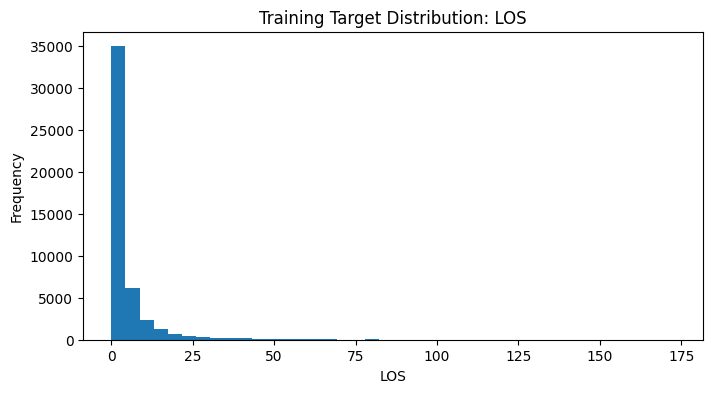

count    47333.000000
mean         5.023395
std          9.721905
min          0.014400
25%          1.150500
50%          2.143900
75%          4.645100
max        173.072500
Name: LOS, dtype: float64

In [8]:
# Target distribution overview

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_df[TARGET_COL], bins=40)
ax.set_title("Training Target Distribution: LOS")
ax.set_xlabel("LOS")
ax.set_ylabel("Frequency")
fig.savefig(
    FIGURES_DIR / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

train_df[TARGET_COL].describe()

### Optional target transformation

ICU Length of Stay is often right-skewed.  
That means a log transformation can sometimes improve stability for linear and boosting models.

This notebook keeps the **original target** as the default setup, because evaluation on the original LOS scale is easier to explain.  
However, an optional `log1p` configuration is included below. You can activate it if needed and compare both versions.

In [9]:
# ===================================
# Optional target transformation flag
# ===================================

USE_LOG_TARGET = False

if USE_LOG_TARGET:
    y_train_full = np.log1p(train_df[TARGET_COL].copy())
    y_test = np.log1p(test_df[TARGET_COL].copy())
    print("Using log1p(LOS) as target.")
else:
    y_train_full = train_df[TARGET_COL].copy()
    y_test = test_df[TARGET_COL].copy()
    print("Using original LOS as target.")

Using original LOS as target.


## Feature and Target Definition

The final model must **not** use:

- `LOS` (the target),
- `SUBJECT_ID`,
- `HADM_ID`,
- `ICUSTAY_ID`.

These identifiers are important for traceability and leakage-safe validation, but they should be excluded from the feature matrix.

As the dataset is already numerically encoded, we will treat all remaining columns as model features.

In [10]:
# Feature and Target Definition

feature_cols = [c for c in train_df.columns if c not in ID_COLS + [TARGET_COL]]

X_train_full = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train_full = train_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

groups = train_df["SUBJECT_ID"].copy()

print("Number of features:", len(feature_cols))
print("X_train shape:", X_train_full.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train_full.shape)
print("y_test shape: ", y_test.shape)

# Sanity check: all feature columns should exist in test set
assert list(X_train_full.columns) == list(X_test.columns), "Train and test feature columns do not match."

# Most prepared versions of the dataset should already be numeric, but this confirms the assumption.
non_numeric_cols = X_train_full.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
print("Non-numeric feature columns:", len(non_numeric_cols))
non_numeric_cols[:20]

Number of features: 1316
X_train shape: (47333, 1316)
X_test shape:  (11792, 1316)
y_train shape: (47333,)
y_test shape:  (11792,)
Non-numeric feature columns: 0


[]

## Cross-Validation Strategy

We use **GroupKFold** with `SUBJECT_ID` as the grouping variable to **prevent patient leakage** during cross-validation. Although each row represents a single ICU stay (`ICUSTAY_ID`), the same patient may appear multiple times in the training set through different stays. Without grouped validation, one stay from a patient could be used for training while another stay from the same patient could appear in validation, leading to overly optimistic performance estimates. GroupKFold ensures that all stays from the same patient remain in the same fold.


In [11]:
train_subjects = set(train_df["SUBJECT_ID"].unique())
test_subjects = set(test_df["SUBJECT_ID"].unique())

overlap = train_subjects.intersection(test_subjects)

print("Train subjects:", len(train_subjects))
print("Test subjects:", len(test_subjects))
print("Overlap:", len(overlap))

Train subjects: 35992
Test subjects: 8998
Overlap: 0


In [12]:
train_stays_per_subject = train_df.groupby("SUBJECT_ID")["ICUSTAY_ID"].nunique()

print("Subjects with >1 ICU stay in train:", (train_stays_per_subject > 1).sum())
print("Max ICU stays for one subject:", train_stays_per_subject.max())

Subjects with >1 ICU stay in train: 6622
Max ICU stays for one subject: 41


In [13]:
# Cross-Validation Strategy

gkf = GroupKFold(n_splits=N_SPLITS)

cv_preview = []
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train_full, y_train_full, groups=groups), start=1):
    train_subjects = set(groups.iloc[tr_idx])
    valid_subjects = set(groups.iloc[va_idx])
    overlap = len(train_subjects.intersection(valid_subjects))
    cv_preview.append({
        "fold": fold,
        "train_rows": len(tr_idx),
        "valid_rows": len(va_idx),
        "train_subjects": len(train_subjects),
        "valid_subjects": len(valid_subjects),
        "subject_overlap": overlap
    })

cv_preview_df = pd.DataFrame(cv_preview)
display(cv_preview_df)

,fold,train_rows,valid_rows,train_subjects,valid_subjects,subject_overlap
0,1,37866,9467,28794,7198,0
1,2,37866,9467,28793,7199,0
2,3,37866,9467,28793,7199,0
3,4,37867,9466,28794,7198,0
4,5,37867,9466,28794,7198,0


## Baseline Models

The first step is to compare a **small, defensible set of baseline models**.
The model set was intentionally chosen to cover different levels of complexity and inductive bias, ranging from a trivial baseline to regularized linear modelling and more expressive non-linear ensemble methods:

1. **DummyRegressor** — included as a minimal baseline to establish the performance of a trivial prediction strategy and verify that the trained models provide meaningful predictive value beyond naive central-tendency estimates.  
2. **Ridge** — included as a regularized linear baseline, particularly suitable for high-dimensional tabular data with potentially correlated predictors, while also offering a relatively interpretable reference model.  
3. **RandomForestRegressor** — included as a non-linear ensemble method capable of modelling complex interactions and non-linear relationships between features without strong distributional assumptions.  
4. **HistGradientBoostingRegressor** — included as a strong boosting-based baseline for tabular data, combining competitive predictive performance with computational efficiency on medium-to-large structured datasets.

In [14]:
# Baseline Models

models = {
    "Dummy": Pipeline([
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "HistGradientBoosting": Pipeline([
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=None,
            max_iter=250,
            random_state=RANDOM_STATE
        ))
    ]),
}

## Cross-Validated Benchmarking

This section benchmarks the candidate models using **GroupKFold** on the training set.

The scoring metrics are:

- **MAE** — used as the main metric because it is directly interpretable in the original unit of the target variable (days of ICU stay). It measures the average absolute prediction error and provides a clear sense of how far predictions are from the true LOS on average. 
- **RMSE** — included because it penalizes large errors more strongly than MAE, making it useful for detecting whether a model performs poorly on extreme or long-stay cases, which are particularly relevant in this dataset due to the strong right-skew of LOS.
- **R²** — included as a complementary goodness-of-fit measure, indicating how much of the variability in LOS is explained by the model relative to a naive mean-based predictor. It is useful for comparing overall explanatory power, although it is less directly interpretable than error-based metrics.
- **Median Absolute Error** — included as a robust summary of typical prediction error, less sensitive to extreme outliers than MAE or RMSE. This is particularly important in LOS prediction because a small number of very long ICU stays can distort average-based error measures. 

In [15]:
# Memory optimization
X_train_full = X_train_full.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train_full = y_train_full.astype(np.float32)
y_test = y_test.astype(np.float32)

In [16]:
# Cross-Validated Benchmarking
cv_results_path = os.path.join(EXPERIMENT_RESULTS_DIR, "baseline_cv_results.csv")

if os.path.exists(cv_results_path):
    print(f"Loading existing CV results from: {cv_results_path}")
    cv_results_df = pd.read_csv(cv_results_path)
else:
    print("No saved CV results found. Running cross-validation...")

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
        "medae": "neg_median_absolute_error"
    }

    cv_results = []

    for name, pipeline in models.items():
        print(f"Running grouped CV for {name}...")
        start = time.time()

        scores = cross_validate(
            pipeline,
            X_train_full,
            y_train_full,
            groups=groups,
            cv=gkf,
            scoring=scoring,
            return_train_score=False,
            n_jobs=1
        )

        elapsed = time.time() - start

        cv_results.append({
            "model": name,
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_mae_std": scores["test_mae"].std(),
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_std": scores["test_rmse"].std(),
            "cv_r2_mean": scores["test_r2"].mean(),
            "cv_r2_std": scores["test_r2"].std(),
            "cv_medae_mean": -scores["test_medae"].mean(),
            "fit_time_seconds": elapsed
        })

    cv_results_df = pd.DataFrame(cv_results).sort_values("cv_mae_mean").reset_index(drop=True)

    cv_results_df.to_csv(cv_results_path, index=False)
    print(f"Saved: {cv_results_path}")

display(cv_results_df)

No saved CV results found. Running cross-validation...
Running grouped CV for Dummy...
Running grouped CV for Ridge...
Running grouped CV for RandomForest...
Running grouped CV for HistGradientBoosting...
Saved: ..\results\9tables_24h\baseline_cv_results.csv


,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,fit_time_seconds
0,HistGradientBoosting,3.141340,0.072552,6.913742,0.143046,0.494041,0.010493,1.371119,104.897135
1,RandomForest,3.259016,0.048179,7.070775,0.119348,0.470725,0.010859,1.319166,8470.287055
2,Ridge,3.935041,0.096267,11.342273,6.430994,-0.851523,2.313192,2.039603,15.898860
3,Dummy,4.776167,0.030694,9.720456,0.167172,-0.000053,0.000064,3.410143,0.754661


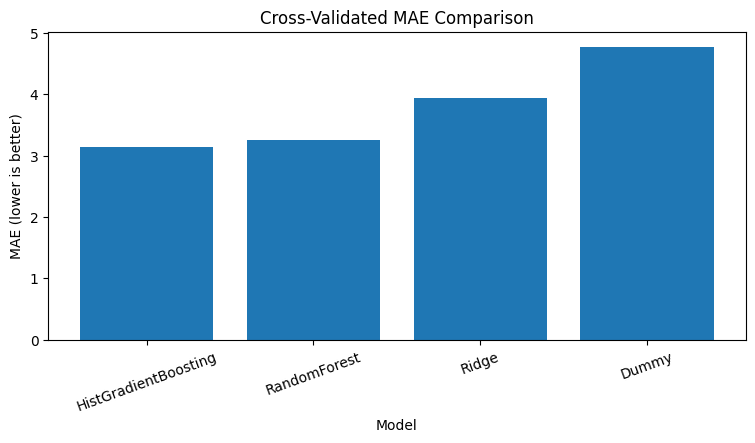

In [17]:
# Quick visualization of CV comparison

fig, ax = plt.subplots(figsize=(9, 4))
ordered = cv_results_df.sort_values("cv_mae_mean")
ax.bar(ordered["model"], ordered["cv_mae_mean"])
ax.set_title("Cross-Validated MAE Comparison")
ax.set_ylabel("MAE (lower is better)")
ax.set_xlabel("Model")
plt.xticks(rotation=20)
fig.savefig(
    FIGURES_DIR / "cv_mae_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Fit Baseline Models and Evaluate on Test Set

After selecting candidate models through cross-validation, each baseline model is fitted on the **full training data** and evaluated on the held-out **test set**.

In [ ]:
USE_LOG_TARGET = False  # Keep False if models were trained on raw LOS values

def maybe_inverse_target(values):
    """
    Invert the target transformation only if log1p(LOS) was used during training.
    """
    values = np.asarray(values)
    if USE_LOG_TARGET:
        return np.expm1(values)
    return values

def regression_metrics(y_true, y_pred):
    """
    Compute regression metrics in the original LOS scale.
    """
    y_true_eval = maybe_inverse_target(y_true)
    y_pred_eval = maybe_inverse_target(y_pred)

    return {
        "MAE": mean_absolute_error(y_true_eval, y_pred_eval),
        "RMSE": np.sqrt(mean_squared_error(y_true_eval, y_pred_eval)),
        "R2": r2_score(y_true_eval, y_pred_eval),
        "MedianAE": median_absolute_error(y_true_eval, y_pred_eval)
    }


# Fit baseline models on the full training set and evaluate on test set

FORCE_RERUN_BASELINE_TEST = False

test_results_path = os.path.join(EXPERIMENT_RESULTS_DIR, "baseline_test_results.csv")
predictions_path = os.path.join(EXPERIMENT_RESULTS_DIR, "baseline_test_predictions.csv")

model_paths = {
    name: os.path.join(EXPERIMENT_MODELS_DIR, f"{name.lower()}_baseline.joblib")
    for name in models.keys()
}

all_model_files_exist = all(os.path.exists(path) for path in model_paths.values())
all_outputs_exist = (
    os.path.exists(test_results_path)
    and os.path.exists(predictions_path)
    and all_model_files_exist
)

if all_outputs_exist and not FORCE_RERUN_BASELINE_TEST:
    print("Loading existing baseline test evaluation artifacts...")

    test_results_df = pd.read_csv(test_results_path)
    baseline_predictions = pd.read_csv(predictions_path)

    fitted_models = {}
    for name, model_path in model_paths.items():
        fitted_models[name] = joblib.load(model_path)
        print(f"Loaded model: {model_path}")

else:
    print("No complete saved baseline artifacts found. Running baseline training and test evaluation...")

    fitted_models = {}
    test_results = []

    # Store test predictions for later analysis (scatter plots, residuals, etc.)
    baseline_predictions = pd.DataFrame({
        "SUBJECT_ID": test_df["SUBJECT_ID"].values,
        "HADM_ID": test_df["HADM_ID"].values,
        "ICUSTAY_ID": test_df["ICUSTAY_ID"].values,
        "y_true": maybe_inverse_target(y_test.to_numpy())
    })

    for name, pipeline in models.items():
        print(f"Fitting {name}...")

        model = clone(pipeline)

        start = time.time()
        model.fit(X_train_full, y_train_full)
        fit_seconds = time.time() - start

        preds = model.predict(X_test)
        metrics = regression_metrics(y_test, preds)

        metrics["model"] = name
        metrics["fit_time_seconds"] = fit_seconds

        fitted_models[name] = model
        test_results.append(metrics)

        # Save predictions in the original target scale
        baseline_predictions[f"{name}_pred"] = maybe_inverse_target(preds)

    # Build results table
    test_results_df = pd.DataFrame(test_results).sort_values("MAE").reset_index(drop=True)

    # Save outputs
    test_results_df.to_csv(test_results_path, index=False)
    print(f"Saved: {test_results_path}")

    baseline_predictions.to_csv(predictions_path, index=False)
    print(f"Saved: {predictions_path}")

    for name, model in fitted_models.items():
        model_filename = f"{name.lower()}_baseline.joblib"
        model_path = os.path.join(EXPERIMENT_MODELS_DIR, model_filename)
        joblib.dump(model, model_path)
        print(f"Saved: {model_path}")

display(test_results_df)

No complete saved baseline artifacts found. Running baseline training and test evaluation...
Fitting Dummy...
Fitting Ridge...
Fitting RandomForest...
Fitting HistGradientBoosting...
Saved: ..\models\9tables_24h\baseline_test_results.csv
Saved: ..\models\9tables_24h\baseline_test_predictions.csv
Saved: ..\models\9tables_24h\dummy_baseline.joblib
Saved: ..\models\9tables_24h\ridge_baseline.joblib
Saved: ..\models\9tables_24h\randomforest_baseline.joblib
Saved: ..\models\9tables_24h\histgradientboosting_baseline.joblib


,MAE,RMSE,R2,MedianAE,model,fit_time_seconds
0,3.062439,6.604138,0.467834,1.317159,HistGradientBoosting,25.155521
1,3.223508,6.813659,0.433532,1.315843,RandomForest,1364.451960
2,3.756271,7.111286,0.382963,2.020093,Ridge,4.434582
3,4.720606,9.053645,-0.000143,3.456896,Dummy,0.001000


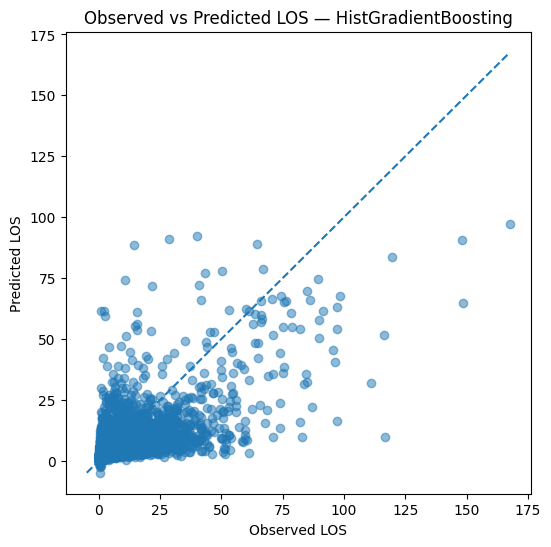

In [20]:
# Observed vs predicted scatter for the best baseline model

best_baseline_name = test_results_df.iloc[0]["model"]
best_baseline_model = fitted_models[best_baseline_name]
best_baseline_preds = maybe_inverse_target(best_baseline_model.predict(X_test))
y_test_eval = maybe_inverse_target(y_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_eval, best_baseline_preds, alpha=0.5)
line_min = min(np.min(y_test_eval), np.min(best_baseline_preds))
line_max = max(np.max(y_test_eval), np.max(best_baseline_preds))
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--")
ax.set_title(f"Observed vs Predicted LOS — {best_baseline_name}")
ax.set_xlabel("Observed LOS")
ax.set_ylabel("Predicted LOS")

fig.savefig(
    FIGURES_DIR / "observed_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Hyperparameter Tuning with Optuna

At this point, a baseline ranking already exists.  
Only the strongest candidates should be tuned:
- `Ridge`
- `HistGradientBoostingRegressor`

In [21]:
# Hyperparameter Tuning with Optuna

TOP_MODELS_TO_TUNE = ["HistGradientBoosting", "RandomForest"]
N_TRIALS = 30
FORCE_RERUN_OPTUNA = False

optuna_results_path = os.path.join(EXPERIMENT_RESULTS_DIR, "optuna_results.csv")

In [22]:
# Helper functions for Optuna tuning

def evaluate_cv_pipeline(pipeline, X, y, groups):
    """
    Evaluate a pipeline with grouped cross-validation using MAE as
    the optimization objective.
    """
    scores = cross_validate(
        pipeline,
        X,
        y,
        groups=groups,
        cv=gkf,
        scoring={"mae": "neg_mean_absolute_error"},
        n_jobs=1,
        return_train_score=False
    )
    return -scores["test_mae"].mean()

def build_hgb_pipeline(
    learning_rate,
    max_depth,
    max_iter,
    min_samples_leaf,
    l2_regularization
):
    return Pipeline([
        ("model", HistGradientBoostingRegressor(
            learning_rate=learning_rate,
            max_depth=max_depth,
            max_iter=max_iter,
            min_samples_leaf=min_samples_leaf,
            l2_regularization=l2_regularization,
            random_state=RANDOM_STATE
        ))
    ])

def build_rf_pipeline(
    n_estimators,
    max_depth,
    min_samples_leaf,
    max_features
):
    return Pipeline([
        ("model", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])


In [23]:
# Run Optuna studies

optuna_summaries = []
studies = {}

if OPTUNA_AVAILABLE:

    if os.path.exists(optuna_results_path) and not FORCE_RERUN_OPTUNA:
        print(f"Loading existing Optuna results from: {optuna_results_path}")
        optuna_results_df = pd.read_csv(optuna_results_path)
        display(optuna_results_df)

    else:
        print("Running Optuna studies...")

        def hgb_objective(trial):
            learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
            max_depth = trial.suggest_int("max_depth", 3, 12)
            max_iter = trial.suggest_int("max_iter", 100, 400)
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 10, 80)
            l2_regularization = trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True)

            pipeline = build_hgb_pipeline(
                learning_rate=learning_rate,
                max_depth=max_depth,
                max_iter=max_iter,
                min_samples_leaf=min_samples_leaf,
                l2_regularization=l2_regularization
            )
            return evaluate_cv_pipeline(pipeline, X_train_full, y_train_full, groups)

        def rf_objective(trial):
            n_estimators = trial.suggest_int("n_estimators", 100, 400, step=50)
            max_depth = trial.suggest_int("max_depth", 5, 30)
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
            max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8])

            pipeline = build_rf_pipeline(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features
            )
            return evaluate_cv_pipeline(pipeline, X_train_full, y_train_full, groups)

        if "HistGradientBoosting" in TOP_MODELS_TO_TUNE:
            print("Tuning HistGradientBoosting...")
            hgb_study = optuna.create_study(direction="minimize", study_name="hgb_mae")
            hgb_study.optimize(hgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
            studies["HistGradientBoosting"] = hgb_study
            optuna_summaries.append({
                "model": "HistGradientBoosting",
                "best_cv_mae": hgb_study.best_value,
                "best_params": str(hgb_study.best_params)
            })

        if "RandomForest" in TOP_MODELS_TO_TUNE:
            print("Tuning RandomForest...")
            rf_study = optuna.create_study(direction="minimize", study_name="rf_mae")
            rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=False)
            studies["RandomForest"] = rf_study
            optuna_summaries.append({
                "model": "RandomForest",
                "best_cv_mae": rf_study.best_value,
                "best_params": str(rf_study.best_params)
            })

        optuna_results_df = pd.DataFrame(optuna_summaries).sort_values("best_cv_mae").reset_index(drop=True)
        display(optuna_results_df)

        optuna_results_df.to_csv(optuna_results_path, index=False)
        print(f"Saved: {optuna_results_path}")

else:
    optuna_results_df = pd.DataFrame()
    print("Skipping Optuna section because Optuna is unavailable.")

[I 2026-05-25 16:13:38,334] A new study created in memory with name: hgb_mae


Running Optuna studies...
Tuning HistGradientBoosting...


[I 2026-05-25 16:14:30,304] Trial 0 finished with value: 3.131867275142007 and parameters: {'learning_rate': 0.12408147797961032, 'max_depth': 8, 'max_iter': 248, 'min_samples_leaf': 56, 'l2_regularization': 0.00023198693196766225}. Best is trial 0 with value: 3.131867275142007.
[I 2026-05-25 16:15:24,776] Trial 1 finished with value: 3.1338165514659018 and parameters: {'learning_rate': 0.10133652187739689, 'max_depth': 8, 'max_iter': 226, 'min_samples_leaf': 59, 'l2_regularization': 0.522912992509044}. Best is trial 0 with value: 3.131867275142007.
[I 2026-05-25 16:16:29,952] Trial 2 finished with value: 3.153769136247902 and parameters: {'learning_rate': 0.056232470502250935, 'max_depth': 8, 'max_iter': 348, 'min_samples_leaf': 47, 'l2_regularization': 0.2564239720844893}. Best is trial 0 with value: 3.131867275142007.
[I 2026-05-25 16:17:29,424] Trial 3 finished with value: 3.140212835668053 and parameters: {'learning_rate': 0.10117125519064193, 'max_depth': 9, 'max_iter': 319, 'min

Tuning RandomForest...


[I 2026-05-25 17:24:50,159] Trial 0 finished with value: 3.1411595770764085 and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_leaf': 5, 'max_features': 0.5}. Best is trial 0 with value: 3.1411595770764085.
[I 2026-05-25 17:25:02,438] Trial 1 finished with value: 3.545536283745709 and parameters: {'n_estimators': 250, 'max_depth': 12, 'min_samples_leaf': 12, 'max_features': 'log2'}. Best is trial 0 with value: 3.1411595770764085.
[I 2026-05-25 17:25:25,973] Trial 2 finished with value: 3.4068584935537047 and parameters: {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 3.1411595770764085.
[I 2026-05-25 21:51:32,573] Trial 3 finished with value: 3.167150997056579 and parameters: {'n_estimators': 200, 'max_depth': 25, 'min_samples_leaf': 3, 'max_features': 0.8}. Best is trial 0 with value: 3.1411595770764085.
[I 2026-05-25 21:55:07,688] Trial 4 finished with value: 3.20466013152138 and parameters: {'n_estim

,model,best_cv_mae,best_params
0,HistGradientBoosting,3.120104,"{'learning_rate': 0.1067725171950778, 'max_dep..."
1,RandomForest,3.129531,"{'n_estimators': 400, 'max_depth': 28, 'min_sa..."


Saved: ..\results\9tables_24h\optuna_results.csv


## Final Model Training and Test Evaluation

This section rebuilds the tuned models from their best parameters, trains them on the full training set, and evaluates them on the held-out test set.

The tuned results can then be compared directly against the baseline benchmark.

In [24]:
tuned_models = {}
tuned_test_results = []

# Store tuned-model predictions for later analysis
tuned_predictions = pd.DataFrame({
    "SUBJECT_ID": test_df["SUBJECT_ID"].values,
    "HADM_ID": test_df["HADM_ID"].values,
    "ICUSTAY_ID": test_df["ICUSTAY_ID"].values,
    "y_true": maybe_inverse_target(y_test.to_numpy())
})

if OPTUNA_AVAILABLE and not optuna_results_df.empty:

    # Convert best_params from string back to dictionary if needed
    optuna_results_df = optuna_results_df.copy()
    optuna_results_df["best_params"] = optuna_results_df["best_params"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    if "HistGradientBoosting" in optuna_results_df["model"].values:
        hgb_params = optuna_results_df.loc[
            optuna_results_df["model"] == "HistGradientBoosting", "best_params"
        ].iloc[0]

        tuned_models["HistGradientBoosting_Tuned"] = build_hgb_pipeline(
            learning_rate=hgb_params["learning_rate"],
            max_depth=hgb_params["max_depth"],
            max_iter=hgb_params["max_iter"],
            min_samples_leaf=hgb_params["min_samples_leaf"],
            l2_regularization=hgb_params["l2_regularization"]
        )

    if "RandomForest" in optuna_results_df["model"].values:
        rf_params = optuna_results_df.loc[
            optuna_results_df["model"] == "RandomForest", "best_params"
        ].iloc[0]

        tuned_models["RandomForest_Tuned"] = build_rf_pipeline(
            n_estimators=rf_params["n_estimators"],
            max_depth=rf_params["max_depth"],
            min_samples_leaf=rf_params["min_samples_leaf"],
            max_features=rf_params["max_features"]
        )

    for name, pipeline in tuned_models.items():
        print(f"Fitting tuned model: {name}...")

        start = time.time()
        pipeline.fit(X_train_full, y_train_full)
        fit_seconds = time.time() - start

        preds = pipeline.predict(X_test)
        metrics = regression_metrics(y_test, preds)

        metrics["model"] = name
        metrics["fit_time_seconds"] = fit_seconds
        tuned_test_results.append(metrics)

        tuned_predictions[f"{name}_pred"] = maybe_inverse_target(preds)

        # Save fitted tuned model
        model_path = os.path.join(EXPERIMENT_MODELS_DIR, f"{name.lower()}.joblib")
        joblib.dump(pipeline, model_path)
        print(f"Saved: {model_path}")

else:
    print("Skipping tuned model evaluation because Optuna results are unavailable.")

# Build results table
tuned_test_results_df = (
    pd.DataFrame(tuned_test_results).sort_values("MAE").reset_index(drop=True)
    if tuned_test_results
    else pd.DataFrame()
)

display(tuned_test_results_df)

# Save outputs
if not tuned_test_results_df.empty:

    tuned_results_path = os.path.join(EXPERIMENT_RESULTS_DIR, "tuned_test_results.csv")
    tuned_preds_path = os.path.join(EXPERIMENT_RESULTS_DIR, "tuned_test_predictions.csv")

    tuned_test_results_df.to_csv(tuned_results_path, index=False)
    tuned_predictions.to_csv(tuned_preds_path, index=False)

    print(f"Saved: {tuned_results_path}")
    print(f"Saved: {tuned_preds_path}")

Fitting tuned model: HistGradientBoosting_Tuned...
Saved: ..\models\9tables_24h\histgradientboosting_tuned.joblib
Fitting tuned model: RandomForest_Tuned...
Saved: ..\models\9tables_24h\randomforest_tuned.joblib


,MAE,RMSE,R2,MedianAE,model,fit_time_seconds
0,3.068429,6.638466,0.462287,1.333673,HistGradientBoosting_Tuned,12.268863
1,3.068895,6.681099,0.455358,1.298854,RandomForest_Tuned,382.361787


Saved: ..\results\9tables_24h\tuned_test_results.csv
Saved: ..\results\9tables_24h\tuned_test_predictions.csv


In [25]:
FORCE_RERUN_FINAL_COMPARISON = False

final_comparison_path = os.path.join(EXPERIMENT_RESULTS_DIR, "final_model_comparison.csv")

if os.path.exists(final_comparison_path) and not FORCE_RERUN_FINAL_COMPARISON:
    print(f"Loading existing final comparison from: {final_comparison_path}")
    final_comparison_df = pd.read_csv(final_comparison_path)

else:
    print("Building consolidated model comparison...")

    frames_to_concat = []

    if 'test_results_df' in globals() and not test_results_df.empty:
        frames_to_concat.append(test_results_df.copy())

    if 'tuned_test_results_df' in globals() and not tuned_test_results_df.empty:
        frames_to_concat.append(tuned_test_results_df.copy())

    if len(frames_to_concat) == 0:
        final_comparison_df = pd.DataFrame()
        print("No model result tables were available for consolidation.")
    else:
        final_comparison_df = (
            pd.concat(frames_to_concat, ignore_index=True)
            .sort_values("MAE")
            .reset_index(drop=True)
        )

        final_comparison_df.to_csv(final_comparison_path, index=False)
        print(f"Saved: {final_comparison_path}")

display(final_comparison_df)

Building consolidated model comparison...
Saved: ..\results\9tables_24h\final_model_comparison.csv


,MAE,RMSE,R2,MedianAE,model,fit_time_seconds
0,3.062439,6.604138,0.467834,1.317159,HistGradientBoosting,25.155521
1,3.068429,6.638466,0.462287,1.333673,HistGradientBoosting_Tuned,12.268863
2,3.068895,6.681099,0.455358,1.298854,RandomForest_Tuned,382.361787
3,3.223508,6.813659,0.433532,1.315843,RandomForest,1364.451960
4,3.756271,7.111286,0.382963,2.020093,Ridge,4.434582
5,4.720606,9.053645,-0.000143,3.456896,Dummy,0.001000


## Model Interpretation

In this project, the final comparison includes both baseline and tuned models, and interpretation is therefore performed only for the top-ranked model after test-set evaluation.

For linear models such as **Ridge**, coefficients can be interpreted directly.  
For non-linear ensemble models such as **Random Forest** or **HistGradientBoosting**, **permutation importance** provides a more appropriate and model-agnostic interpretation method.

In [26]:
# Model Interpretation

FORCE_RERUN_IMPORTANCE = False

importance_path = os.path.join(EXPERIMENT_RESULTS_DIR, "permutation_importance.csv")

# Select the best available model: tuned if available, otherwise best baseline
if 'final_comparison_df' in globals() and not final_comparison_df.empty:
    best_model_name = final_comparison_df.iloc[0]["model"]
elif 'tuned_test_results_df' in globals() and not tuned_test_results_df.empty:
    best_model_name = tuned_test_results_df.iloc[0]["model"]
else:
    best_model_name = test_results_df.iloc[0]["model"]

# Recover the fitted best model
if 'tuned_models' in globals() and best_model_name in tuned_models:
    best_model = tuned_models[best_model_name]
elif 'fitted_models' in globals() and best_model_name in fitted_models:
    best_model = fitted_models[best_model_name]
else:
    raise ValueError(f"Best model '{best_model_name}' was not found in fitted model dictionaries.")

print("Best model selected for interpretation:", best_model_name)

if os.path.exists(importance_path) and not FORCE_RERUN_IMPORTANCE:
    print(f"Loading existing permutation importance from: {importance_path}")
    importance_df = pd.read_csv(importance_path)

else:
    print("Computing permutation importance...")

    start = time.time()
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=1
    )
    elapsed = time.time() - start

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    print(f"Permutation importance computed in {elapsed:.2f} seconds.")

    importance_df.to_csv(importance_path, index=False)
    print(f"Saved: {importance_path}")

display(importance_df.head(20))

Best model selected for interpretation: HistGradientBoosting
Computing permutation importance...
Permutation importance computed in 2348.64 seconds.
Saved: ..\results\9tables_24h\permutation_importance.csv


,feature,importance_mean,importance_std
0,chart_834_count,0.233760,0.007743
1,missingindicator_output_43175_sum,0.109395,0.005364
2,missingindicator_lab_50983_std,0.020333,0.002565
3,chart_211_min,0.017595,0.001874
4,LAST_CAREUNIT_SICU,0.015754,0.001232
5,chart_211_count,0.015632,0.000469
6,chart_723_last,0.013735,0.000702
7,missingindicator_drug_d5w_count,0.012650,0.002544
8,chart_198_last,0.010829,0.000772
9,FIRST_CAREUNIT_SICU,0.010626,0.000751


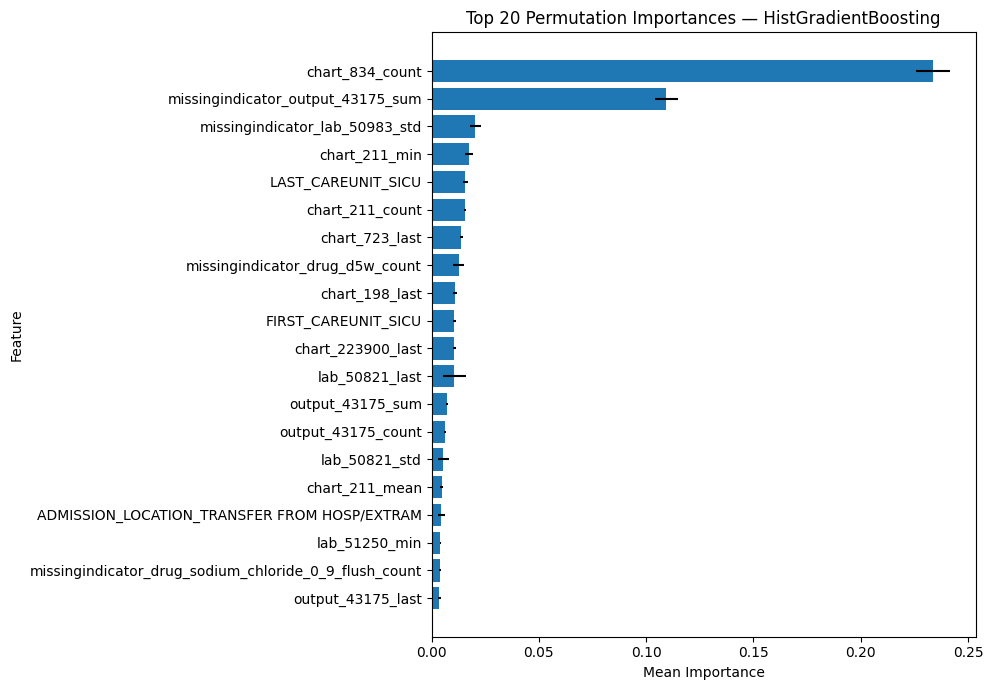

In [27]:
top_k = 20
top_importance = (
    importance_df.sort_values("importance_mean", ascending=False)
    .head(top_k)
    .sort_values("importance_mean")
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"]
)
ax.set_title(f"Top {top_k} Permutation Importances — {best_model_name}")
ax.set_xlabel("Mean Importance")
ax.set_ylabel("Feature")
plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Save Results and Artifacts

A professional training workflow should persist its results.

This section saves:

- baseline CV results,
- baseline test results,
- final comparison table,
- permutation importances,
- and the final selected model.

If you want to save preprocessing + model together in a production-style pipeline, that can also be added later.

In [28]:
# Determine best final model
best_final_name = final_comparison_df.iloc[0]["model"]
best_final_model = tuned_models.get(best_final_name, fitted_models.get(best_final_name))

# Save best model
model_filename = f"{best_final_name.lower().replace(' ', '_')}.joblib"
model_path = os.path.join(EXPERIMENT_MODELS_DIR, model_filename)
joblib.dump(best_final_model, model_path)

# Save run summary
summary_payload = {
    "best_model": best_final_name,
    "use_log_target": USE_LOG_TARGET,
    "n_features": len(feature_cols),
    "train_shape": list(train_df.shape),
    "test_shape": list(test_df.shape),
    "results_file": os.path.join(EXPERIMENT_RESULTS_DIR, "final_model_comparison.csv"),
    "importance_file": os.path.join(EXPERIMENT_RESULTS_DIR, "permutation_importance.csv"),
    "saved_model": model_path
}

summary_path = os.path.join(EXPERIMENT_RESULTS_DIR, "run_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("Saved model:", model_path)
print("Saved run summary:", summary_path)

Saved model: ..\models\9tables_24h\histgradientboosting.joblib
Saved run summary: ..\results\9tables_24h\run_summary.json
